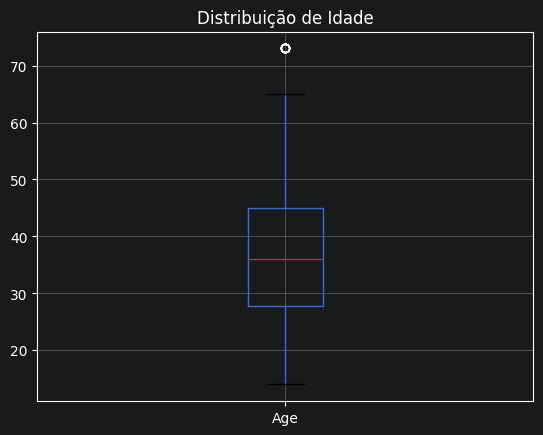

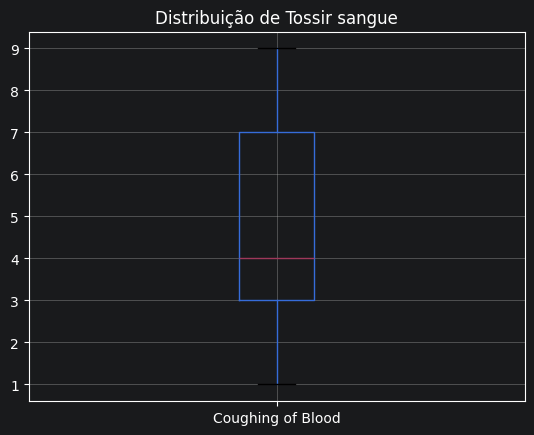




Outliers encontrados:
      Patient Id  Age  Gender  Air Pollution  Alcohol use  Dust Allergy  \
index                                                                     
15          P111   73       1              5            6             6   
126         P211   73       1              5            6             6   
237         P311   73       1              5            6             6   
348         P411   73       1              5            6             6   
459         P511   73       1              5            6             6   
570         P611   73       1              5            6             6   
681         P711   73       1              5            6             6   
792         P811   73       1              5            6             6   
889           P9   73       1              5            6             6   
903         P911   73       1              5            6             6   

       OccuPational Hazards  Genetic Risk  chronic Lung Disease  \
index  

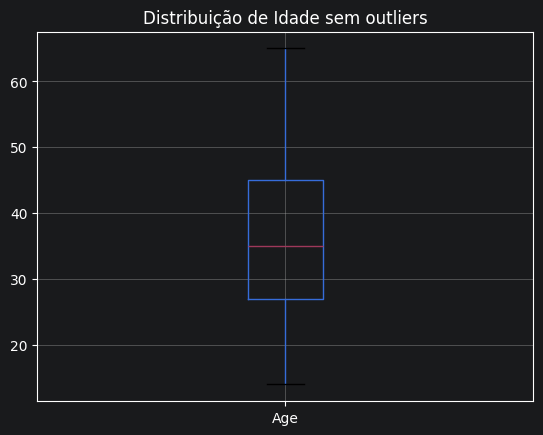

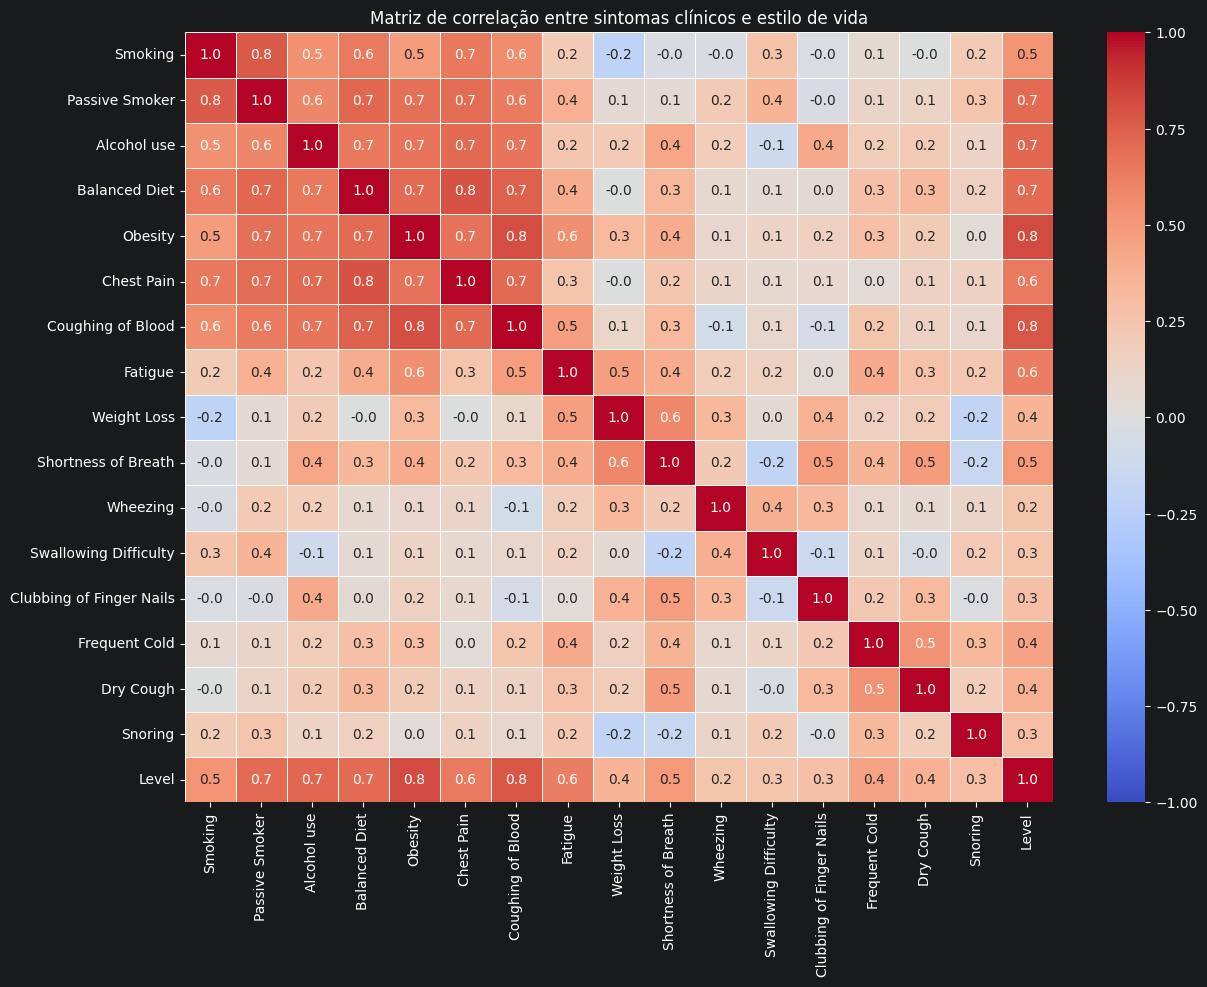

252
285


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from scipy.stats import skew
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

df_1 = pd.read_csv('Dataset(1).csv', index_col='index')

#df_1.head()
#df_1.info()

#DUPLICADOS - SEM DUPLICADOS
#duplicados = df_1[df_1.duplicated(keep='first')]
#print(duplicados)

#VENDO SE TEM NaN - NÃO TEM NAN
#check_null = pd.isnull(df_1)
#print(check_null) #- Sem nulos. check null retornou false, portanto sem nulos.

#Descobrimos que os registros após 999 são todos preenchidos por zeros. Quando se faz a checagem dos valores nulos eles passam despercebidos.

#REMOVENDO OS ZEROS - TINHA, REGISTROS APOS O 999
df_1 = df_1[df_1['Patient Id'] != '0']

#Transformar level em valor numérico
mapa = {'Low': 0, 'Medium': 1, 'High': 2}
df_1['Level'] = df_1['Level'].map(mapa)

#OUTLIERS
#gráfico dificil de compreender, porem ajudou a achar os valores 0s
#sns.scatterplot(x=range(len(df_1['Age'])), y=df_1['Age'])
#plt.title("Scatter Plot for Age")
#plt.show()

df_1.boxplot(column='Age')
plt.title('Distribuição de Idade')
plt.show()

#Verificando em Coughing of Blood - não tem
df_1.boxplot(column='Coughing of Blood')
plt.title('Distribuição de Tossir sangue')
plt.show()

print("\n\n")

#Vendo os limites superiores, inferiores e quartis
q1 = df_1['Age'].quantile(0.25)
q3 = df_1['Age'].quantile(0.75)
IQR = q3-q1
lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR
outliers = df_1[(df_1['Age'] < lower_limit) | (df_1['Age'] > upper_limit)]
print(f'Outliers encontrados:\n{outliers}')

#Removendo os outliers
df_sem_outlier = df_1[(df_1['Age'] >= lower_limit) & (df_1['Age'] <= upper_limit)]
#print(len(df_1))
#print(len(df_sem_outlier))
df_1 = df_sem_outlier

df_1.boxplot(column='Age')
plt.title('Distribuição de Idade sem outliers')
plt.show()
#df_1.to_csv("Dataset(1).csv")

#Verificando os parametros
df_1.max()

print("\n\n")

#Matriz de correlação
colunas_selecionadas = ["Smoking", "Passive Smoker", "Alcohol use", "Balanced Diet", "Obesity", "Chest Pain", "Coughing of Blood", "Fatigue", "Weight Loss",
                        "Shortness of Breath", "Wheezing", "Swallowing Difficulty", "Clubbing of Finger Nails", "Frequent Cold", "Dry Cough", "Snoring", "Level"]

matriz = df_1[colunas_selecionadas].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(matriz, annot=True, fmt=".1f", linewidths=.6, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlação entre sintomas clínicos e estilo de vida")
plt.show()

totalh = len(df_1[(df_1['Gender'] == 1) & (df_1['Level'] == 2)])
print(totalh)

totalFumoBebida = len(df_1[(df_1['Smoking'] > 1) & (df_1['Alcohol use'] > 6)])
print(totalFumoBebida)  